In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# project imports
from sim.camera import Camera
from sim.lens import Lens
from sim.frame import make_blank_frame
from sim.render import render, RenderConfig, plot_render_stages

Derived-ZP sanity checks (noiseless):
  sky level (median): 0.029999999329447746
  stars_post_psf max: 40.40174102783203
  (mean - sky) max  : 40.40174102783203
  final max         : 40.431739807128906

Noise sanity checks (sky patch):
  pre  mean/var: 0.029999999329447746 0.0
  post mean/var: -0.02075209468603134 24.950328826904297


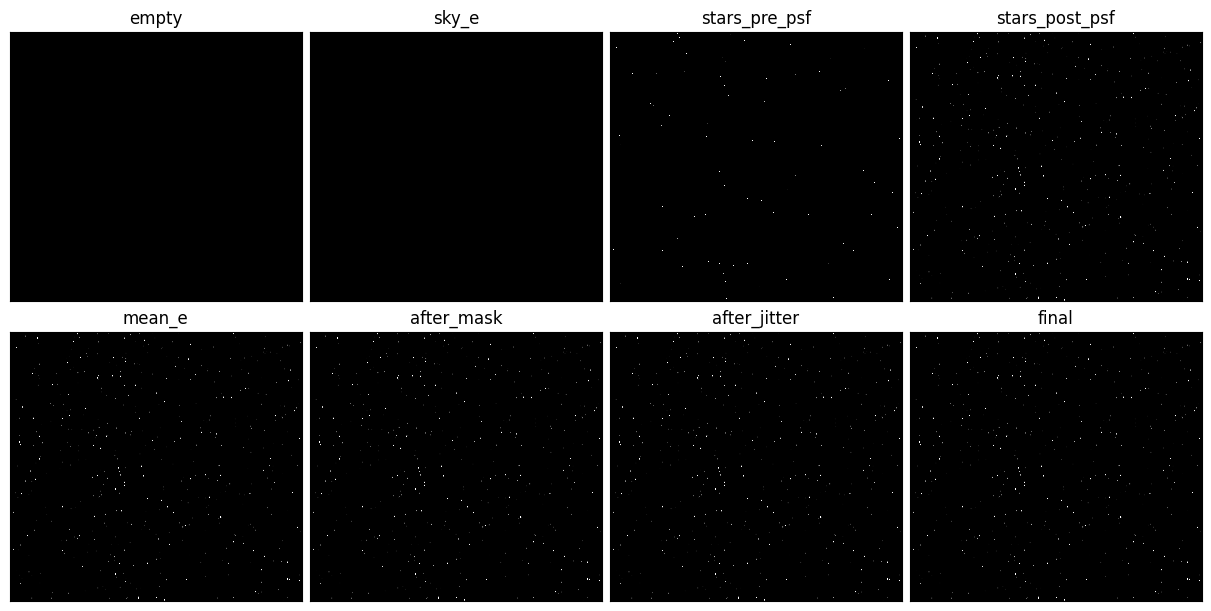

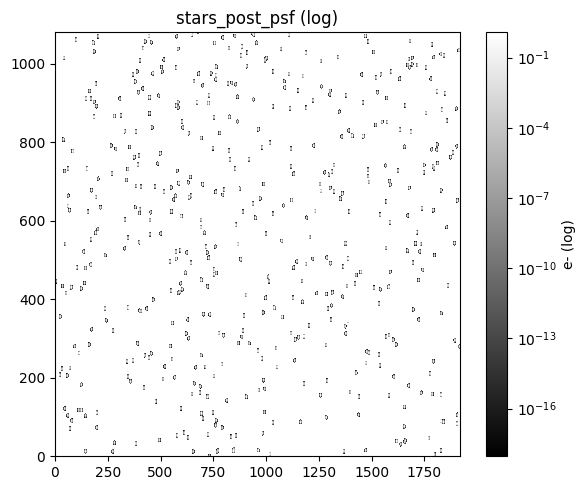

In [3]:
STAR_CSV = "sim/physics/starfields/field2.csv"

RA0_DEG  = 40.0
DEC0_DEG = 70.0
ROT_DEG  = 0.0

cam = Camera(
    nx=1920,
    ny=1080,
    pixel_um=3.75,
    read_noise_e=0.0,
    gain_e_per_adu=1.0,
    qe=0.6,
)

lens = Lens(
    focal_mm=120.0,
    f_number=2.0,
    transmission=0.9
)

# Pick a short exposure because derived ZP is huge
cfg0 = RenderConfig(
    exposure_s=0.01,
    sky_e_per_px_s=3.0,       # sky ~0.03 e-/px at 0.01s
    zeropoint_e_per_s=0.0,    # IMPORTANT: 0 => derive from optics
    psf_sigma_px=1.2,
    read_noise_e=0.0,
    enable_psf=True,
    enable_mask=False,
    enable_jitter=False,
    enable_noise=False,
    seed=123,
)

cfg1 = RenderConfig(
    exposure_s=0.01,
    sky_e_per_px_s=3.0,
    zeropoint_e_per_s=0.0,    # IMPORTANT
    psf_sigma_px=1.2,
    read_noise_e=5.0,
    enable_psf=True,
    enable_mask=False,
    enable_jitter=False,
    enable_noise=True,
    seed=123,
)

# --- render noiseless ---
frame0 = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)
frame0, res0 = render(frame0, cfg0, stars=STAR_CSV)

# --- render noisy ---
frame1 = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)
frame1, res1 = render(frame1, cfg1, stars=STAR_CSV)

# --- key checks ---
print("Derived-ZP sanity checks (noiseless):")
print("  sky level (median):", float(np.median(res0.sky_e)))
print("  stars_post_psf max:", float(np.max(res0.stars_e_post_psf)))
print("  (mean - sky) max  :", float(np.max(res0.mean_e - res0.sky_e)))
print("  final max         :", float(np.max(res0.final_e)))

print("\nNoise sanity checks (sky patch):")
patch0 = res0.final_e[200:300, 200:300]
patch1 = res1.final_e[200:300, 200:300]
print("  pre  mean/var:", float(np.mean(patch0)), float(np.var(patch0)))
print("  post mean/var:", float(np.mean(patch1)), float(np.var(patch1)))

# --- stage plot (should show pinpoint -> PSF broadened -> carries through) ---
plot_render_stages(frame0, res0, cmap="gray", stretch="asinh", shared_scale=True)

# --- quick log display of stars_post_psf (just to confirm they exist clearly) ---
img = res0.stars_e_post_psf
pos = img[img > 0]
vmin = np.percentile(pos, 1)
vmax = np.percentile(pos, 99.9)

plt.figure(figsize=(6,5))
plt.imshow(img, origin="lower", cmap="gray", norm=LogNorm(vmin=vmin, vmax=vmax), interpolation="nearest", aspect="auto")
plt.colorbar(label="e- (log)")
plt.title("stars_post_psf (log)")
plt.tight_layout()
plt.show()

In [4]:
# Use noiseless components for SNR estimate
sky_level = float(np.median(res0.sky_e))
peak_star = float(np.max(res0.stars_e_post_psf))

print("Sky level (e-/px):", sky_level)
print("Peak star (e-/px):", peak_star)
print("Peak/sky ratio:", peak_star / max(1e-12, sky_level))

# find brightest star center (use pre-PSF for crisp peak location)
y0, x0 = np.unravel_index(np.argmax(res0.stars_e_pre_psf), res0.stars_e_pre_psf.shape)

# aperture photometry on post-PSF star layer
r_ap = 3  # pixels
yy, xx = np.indices(res0.stars_e_post_psf.shape)
rr2 = (xx - x0)**2 + (yy - y0)**2
ap = rr2 <= (r_ap**2)

F_star = float(np.sum(res0.stars_e_post_psf[ap]))
Npix = int(np.sum(ap))
F_sky = sky_level * Npix
sig_read = float(getattr(cfg1, "read_noise_e", 0.0))

snr = F_star / np.sqrt(max(1e-12, F_star + F_sky + Npix * sig_read**2))

print("\nAperture stats (r={} px):".format(r_ap))
print("  F_star (e-):", F_star)
print("  F_sky  (e-):", F_sky)
print("  Npix:", Npix)
print("  read noise sigma (e-):", sig_read)
print("  SNR estimate:", snr)

Sky level (e-/px): 0.029999999329447746
Peak star (e-/px): 40.40174102783203
Peak/sky ratio: 1346.7247310293778

Aperture stats (r=3 px):
  F_star (e-): 408.3330383300781
  F_sky  (e-): 0.8699999805539846
  Npix: 29
  read noise sigma (e-): 5.0
  SNR estimate: 12.12464738387536


Sky electrons / px: 2.265517473220825
Star peak electrons / px: 4040.174072265625
Mean peak (star+sky): 4042.439697265625
Peak / sky ratio: 1783.3338828862875

Noise stats (background patch):
  mean: 2.5967178344726562
  var : 111.2315902709961
  expected variance ~ sky + read^2 = 27.265517473220825


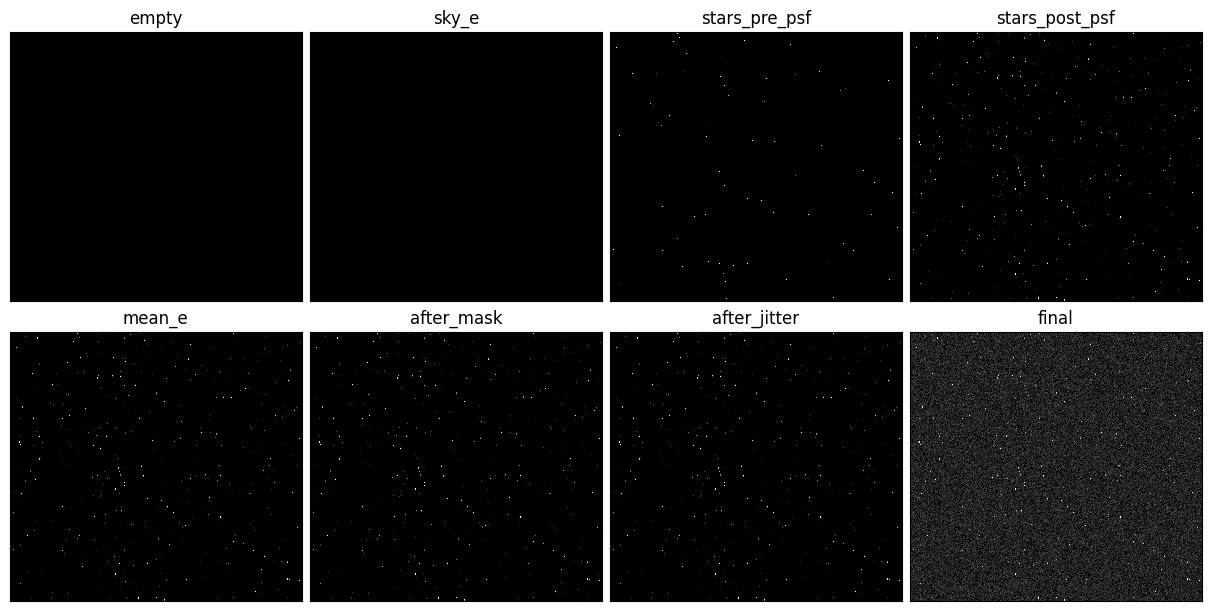

In [6]:
# ===============================
# FULL PIPELINE TEST (derived sky + stars + PSF + noise)
# ===============================

STAR_CSV = "sim/physics/starfields/field2.csv"

RA0_DEG  = 40.0
DEC0_DEG = 70.0
ROT_DEG  = 0.0

cam = Camera(
    nx=1920,
    ny=1080,
    pixel_um=3.75,
    read_noise_e=0.0,
    gain_e_per_adu=1.0,
    qe=0.6,
)

lens = Lens(
    focal_mm=120.0,
    f_number=2.0,
    transmission=0.9
)

# Choose realistic dark sky
cfg = RenderConfig(
    exposure_s=1.0,
    sky_e_per_px_s=0.0,               # IMPORTANT: 0 => derive from mu
    sky_mu_mag_per_arcsec2=21.0,      # dark sky
    zeropoint_e_per_s=0.0,            # derive ZP from optics
    psf_sigma_px=1.2,
    read_noise_e=5.0,
    enable_psf=True,
    enable_mask=False,
    enable_jitter=False,
    enable_noise=True,
    seed=42,
)

frame = make_blank_frame(cam, lens,
                         ra0_deg=RA0_DEG,
                         dec0_deg=DEC0_DEG,
                         rot_deg=ROT_DEG)

frame, res = render(frame, cfg, stars=STAR_CSV)

# -----------------------
# Diagnostic prints
# -----------------------

sky_level = float(np.median(res.sky_e))
star_peak = float(np.max(res.stars_e_post_psf))
mean_peak = float(np.max(res.mean_e))

print("Sky electrons / px:", sky_level)
print("Star peak electrons / px:", star_peak)
print("Mean peak (star+sky):", mean_peak)
print("Peak / sky ratio:", star_peak / max(1e-12, sky_level))

# Noise sanity (background patch)
patch = res.final_e[200:400, 200:400]
print("\nNoise stats (background patch):")
print("  mean:", float(np.mean(patch)))
print("  var :", float(np.var(patch)))

expected_var = sky_level + cfg.read_noise_e**2
print("  expected variance ~ sky + read^2 =", expected_var)

# -----------------------
# Stage visualization
# -----------------------

plot_render_stages(frame, res,
                   cmap="gray",
                   stretch="asinh",
                   shared_scale=True)